#Project Title: **Popcorn Picks**

**Objective**

Analyze movie trends, ratings, popularity and genres using:

- NumPy
- Pandas
- Matplotlib
- Seaborn

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
file_path_relative = "../data/mymoviedb.csv"
file_path_current = "mymoviedb.csv"
df = None
file_to_read = None

if os.path.exists(file_path_relative):
    file_to_read = file_path_relative
elif os.path.exists(file_path_current):
    file_to_read = file_path_current
else:
    print(f"Error: Neither '{file_path_relative}' nor '{file_path_current}' found.")

if file_to_read:
    print(f"Attempting to read file: {file_to_read}")
    print("\n--- First 10 lines of the file ---")
    !head -n 10 "{file_to_read}"
    print("------------------------------------\n")

    try:

        df = pd.read_csv(file_to_read, engine='python', on_bad_lines='skip')
        print("Successfully read with engine='python', on_bad_lines='skip'")
    except pd.errors.ParserError as e:
        print(f"Failed to parse CSV with the current settings. Error: {e}")
        print("Please review the file header above and try uncommenting different pd.read_csv options.")
    except FileNotFoundError:
        print(f"File not found at '{file_to_read}'. Please ensure the path is correct.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if df is not None:
    print("\nDataFrame head successfully loaded:")
    print(df.head())

Attempting to read file: ../data/mymoviedb.csv

--- First 10 lines of the file ---
------------------------------------

Successfully read with engine='python', on_bad_lines='skip'

DataFrame head successfully loaded:
  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                

'head' is not recognized as an internal or external command,
operable program or batch file.


Dataset Overview
- Shape
- Columns
- Datatypes
- info
- Top 10 rows
- Bottom 10 rows
- Describe

In [3]:
df.shape

(9837, 9)

In [4]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='str')

In [5]:
df.dtypes

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [7]:
df.head(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022-01-07,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022-02-10,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,2022-02-17,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,2021-11-03,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [8]:
df.tail(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9827,2005-05-18,I'm in Love With My Little Sister,Yori and his twin sister Iku used to be very c...,13.360,9,5.7,ja,"Romance, Animation, Drama",https://image.tmdb.org/t/p/original/fRdxgR85XX...
9828,2013-08-23,All Is Lost,"During a solo voyage in the Indian Ocean, a ve...",13.359,1319,6.6,en,"Action, Adventure, Drama",https://image.tmdb.org/t/p/original/9cVA4oX2xH...
9829,2008-05-13,Amateur Porn Star Killer 2,Shane Ryan's sequel to the disturbing Amateur ...,13.359,14,5.4,en,"Crime, Horror",https://image.tmdb.org/t/p/original/iBmngXVhDu...
9830,1992-06-26,Unlawful Entry,"After a break-in at their house, a couple gets...",13.358,199,6.1,en,"Crime, Thriller, Mystery",https://image.tmdb.org/t/p/original/sKUk1ca6gH...
9831,1974-11-06,The Little Prince,"Based on the story by Antoine deSaint-Exupery,...",13.357,89,6.6,en,"Science Fiction, Fantasy, Family, Music",https://image.tmdb.org/t/p/original/ts0TGlxlBf...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


In [9]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


Data Cleaning
- Missing values
- Duplicate records
- Remove duplicates

In [10]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

Numpy Analysis
- Convert popularity to numpy array
- Mean popularity
- Mode
- Median popularity
- Standard deviation
- Maximum Popularity
- Minimum popularity
- Percentile popularity

In [13]:
popularity = np.array(df["Popularity"].dropna())

In [14]:
np.mean(popularity)

np.float64(40.32056996031343)

In [15]:
df["Original_Language"].mode()[0]

'en'

In [16]:
df["Genre"].mode()[0]

'Drama'

In [17]:
np.median(popularity)

np.float64(21.191)

In [18]:
np.std(popularity)

np.float64(108.86876803976638)

In [19]:
np.max(popularity)

np.float64(5083.954)

In [20]:
np.min(popularity)

np.float64(7.1)

In [21]:
np.percentile(popularity,[25,50,75])

array([16.1275, 21.191 , 35.1745])

PANDAS ANALYSIS
- Most Popular Movie
- Top 10 Popular Movies
- Top 10 languages
- Top 10 genre

In [22]:
df.loc[df["Popularity"].idxmax()]

Release_Date                                                2021-12-15
Title                                          Spider-Man: No Way Home
Overview             Peter Parker is unmasked and no longer able to...
Popularity                                                    5083.954
Vote_Count                                                        8940
Vote_Average                                                       8.3
Original_Language                                                   en
Genre                               Action, Adventure, Science Fiction
Poster_Url           https://image.tmdb.org/t/p/original/1g0dhYtq4i...
Name: 0, dtype: object

In [23]:
df.nlargest(10,"Popularity")[["Title","Popularity"]]

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [24]:
df["Original_Language"].value_counts().head(10)

Original_Language
en    7569
ja     645
es     339
fr     292
ko     170
zh     129
it     123
cn     109
ru      83
de      82
Name: count, dtype: int64

In [25]:
df["Genre"].value_counts().head(10)

Genre
Drama                     466
Comedy                    403
Drama, Romance            248
Horror                    238
Horror, Thriller          199
Comedy, Romance           196
Documentary               139
Comedy, Drama             137
Action, Thriller          125
Comedy, Drama, Romance    107
Name: count, dtype: int64

**MATPLOTLIB VISUALIZATION**

**Popularity Distribution**

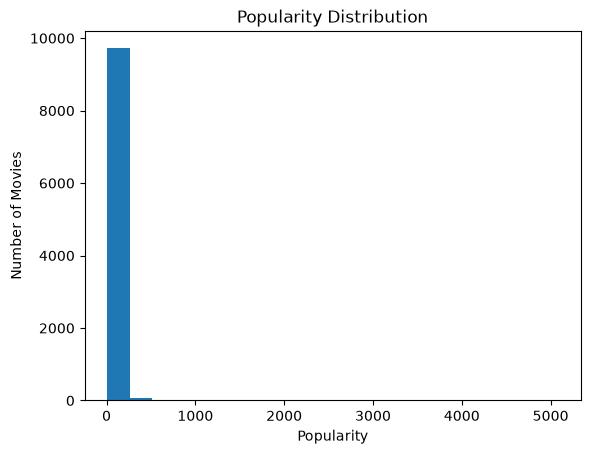

In [26]:
plt.hist(df["Popularity"],bins=20)

plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.savefig("../images/popularity_distribution.png",
            bbox_inches="tight")

plt.show()

**Vote Age Distribution**

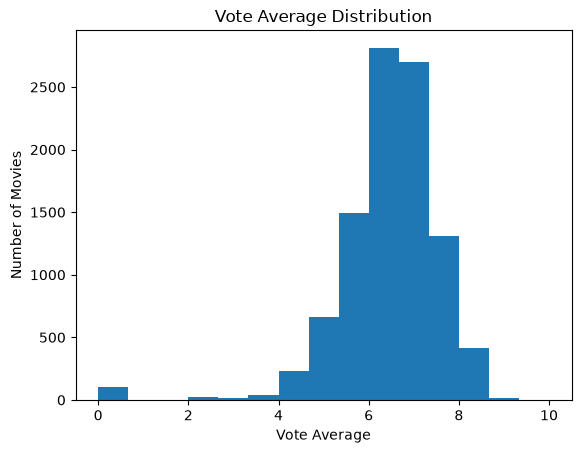

In [27]:
df["Vote_Average"] = pd.to_numeric(df["Vote_Average"], errors='coerce')
plt.hist(df["Vote_Average"].dropna(), bins=15)

plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.savefig(
    "../images/rating_distribution.png",
    bbox_inches="tight"
)

plt.show()

**Top Genres**

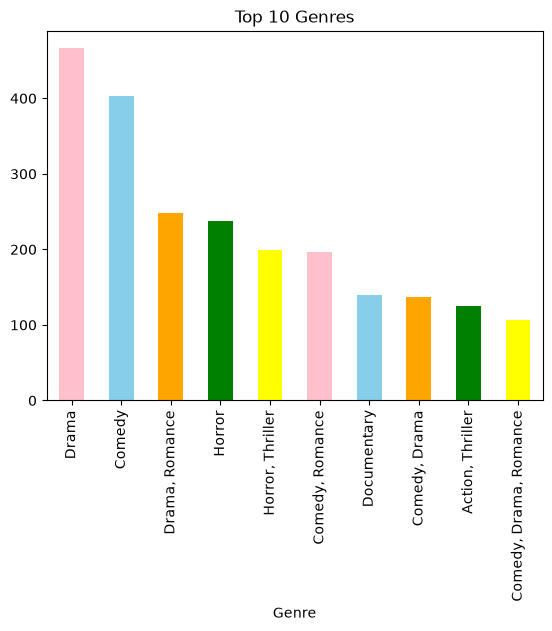

In [28]:
df["Genre"].value_counts().head(10).plot(kind="bar", color=["pink","skyblue","orange","green","yellow"])
plt.title("Top 10 Genres")
plt.savefig("../images/genre_distribution.png",
            bbox_inches="tight")
plt.show()

**Population vs rating**

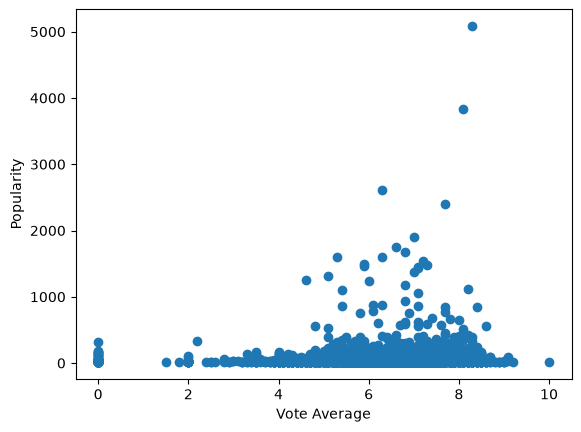

In [29]:
plt.scatter(
    df["Vote_Average"],
    df["Popularity"]
)

plt.xlabel("Vote Average")
plt.ylabel("Popularity")
plt.savefig(
    "../images/popularity_vs_rating.png",
    bbox_inches="tight"
)

plt.show()

**SEABORN VISUALIZATION**

COUNTPLOT VISUALIZATION

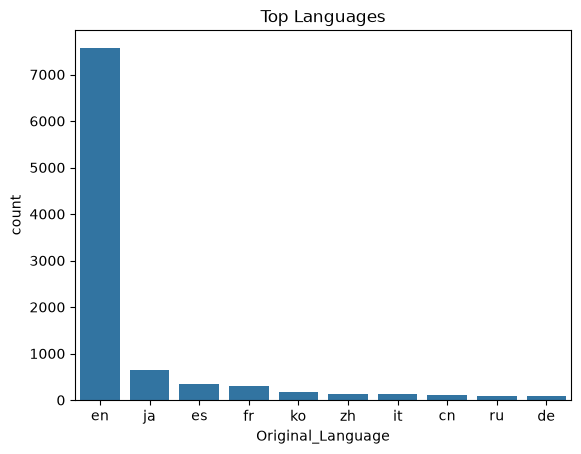

In [30]:
sns.countplot(
    x=df["Original_Language"],
    order=df["Original_Language"].value_counts().head(10).index
)

plt.title("Top Languages")
plt.savefig(
    "../images/language_distribution.png",
    bbox_inches="tight")

plt.show()

**Pairplot**

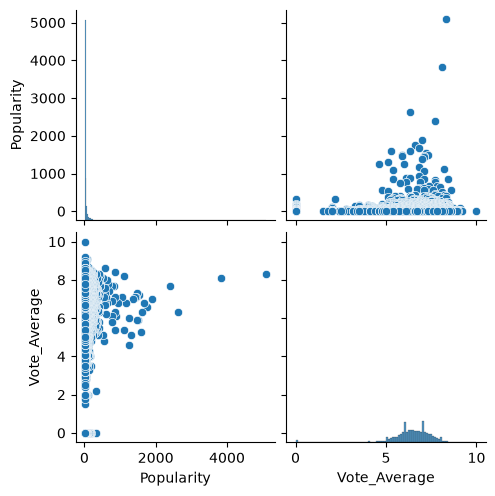

In [31]:
sns.pairplot(
    df[
        [
            "Popularity",
            "Vote_Count",
            "Vote_Average"
        ]
    ]
)
plt.savefig(
    "../images/pairplot.png",
    bbox_inches="tight"
)

plt.show()

Pairplot shows the relationship among popularity, vote count and vote average. Popularity and vote count appear positively related.

**HEATMAP**

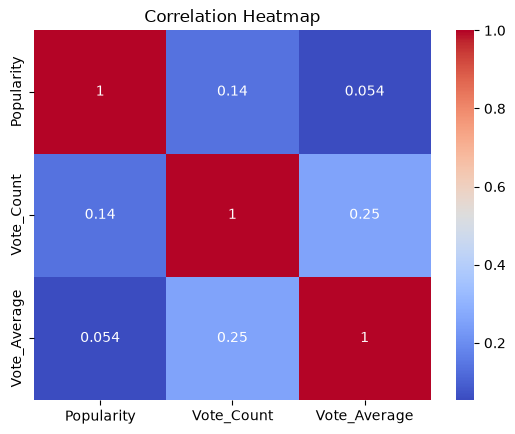

In [32]:
df["Vote_Count"] = pd.to_numeric(df["Vote_Count"], errors='coerce')

corr = df[
    [
        "Popularity",
        "Vote_Count",
        "Vote_Average"
    ]
].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("../images/heatmap.png",
            bbox_inches="tight")
plt.show()

The heatmap indicates the strength of correlation between popularity, vote count and vote average.

#Key Findings
1. The most popular movie in the dataset is **Spider-Man: No Way Home**
2. Most Common Language is **en**
3. The Most Frequent genre is **Drama**
4. The second popular movie is **The Batman**
5. Count of Comedy and Romance **196**
6. Median of popularity **21.191**
7. Maximum Popularity is **5083.954**
8. Massive Breakout hits only occur withiin the **6.0-8.5** ratings sweet spot.
9. While ratings (Vote_Average) stay consistently bell-curved around **6.5**, a spike in a movie's Popularity triggers a massive, exponential rise in its total Vote_Count.
10. The heatmap shows very weak linear correlations across all metrics, with Vote_Count and Vote_Average having the highest—yet still weak—positive relationship at just **0.25**.